In [1]:
!pip install -r requirements.txt


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import _tree
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})

ARQUIVO = 'nij-challenge2021_full_dataset.csv'
LABEL = 'Recidivism_Within_3years'
SEED = 42

c:\Users\lucas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\lucas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Preparação dos Dados (Data Preparation)

Seleciona, limpa, transforma e formata os dados para modelagem. Esta etapa costuma consumir a maior parte do tempo do projeto (60-70%).

In [3]:
df = pd.read_csv("dados/dados_transformados.csv")
df.head()

,Gender,Race,Age_at_Release,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,Prison_Years,...,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,1,0,5,0.0,3.0,2.0,0,3,0.0,3,...,2,612.000000,0,0,0,0,1,0.447610,0,1
1,1,0,3,0.0,6.0,1.0,2,1,3.0,3,...,2,35.666667,0,0,0,0,1,2.000000,0,0
2,1,0,6,0.0,7.0,0.0,0,3,0.0,0,...,0,93.666667,1,0,1,0,0,0.000000,0,0
3,1,1,4,0.0,7.0,0.0,2,1,2.0,0,...,3,25.400000,0,0,0,0,2,0.718996,0,1
4,1,1,3,0.0,4.0,1.0,2,3,3.0,0,...,0,23.117647,0,0,1,0,1,0.929389,0,0


# Modelagem

In [4]:
FEATURES = [c for c in df.columns if c != LABEL]

X = df[FEATURES]
y = df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

print(f"Treino : {X_train.shape[0]:,} registros")
print(f"Teste  : {X_test.shape[0]:,} registros")
print(f"\nProporção da label no treino :")
print((y_train.value_counts(normalize=True) * 100).round(1))
print(f"\nProporção da label no teste  :")
print((y_test.value_counts(normalize=True) * 100).round(1))

Treino : 18,084 registros
Teste  : 7,751 registros

Proporção da label no treino :
Recidivism_Within_3years
0    57.7
1    42.3
Name: proportion, dtype: float64

Proporção da label no teste  :
Recidivism_Within_3years
0    57.7
1    42.3
Name: proportion, dtype: float64


In [5]:
def _extrair_folhas_roc(modelo, feature_names, X_te, y_te):
    """Extrai pontos operacionais (FPR, TPR) de cada folha da árvore para o ROC."""
    tree = modelo.tree_
    feature_names = list(feature_names)

    # Obter o índice da folha para cada amostra de teste
    folha_ids = modelo.apply(X_te)
    y_arr = np.array(y_te)

    total_pos = (y_arr == 1).sum()
    total_neg = (y_arr == 0).sum()

    # Para cada folha, calcular proporção de positivos (pureza)
    folhas_unicas = np.unique(folha_ids)
    folhas_info = []

    for fid in folhas_unicas:
        mask = folha_ids == fid
        n = mask.sum()
        n_pos = (y_arr[mask] == 1).sum()
        n_neg = (y_arr[mask] == 0).sum()
        pureza = n_pos / n if n > 0 else 0
        gini = round(float(tree.impurity[fid]), 4)

        # Reconstruir o caminho (regras) até esta folha
        caminho = _caminho_folha(tree, fid, feature_names)

        folhas_info.append({
            'id': int(fid),
            'n': n, 'n_pos': n_pos, 'n_neg': n_neg,
            'pureza': pureza,
            'pct_reincid': round(pureza * 100, 1),
            'gini': gini,
            'caminho': caminho,
            'fpr_contrib': n_neg / total_neg if total_neg > 0 else 0,
            'tpr_contrib': n_pos / total_pos if total_pos > 0 else 0,
        })

    # Ordenar por pureza decrescente (folhas mais "positivas" primeiro)
    folhas_info.sort(key=lambda x: x['pureza'], reverse=True)

    # Acumular FPR e TPR para traçar o polígono ROC
    fpr_acum = [0.0]
    tpr_acum = [0.0]
    labels = ['Origem (0,0)']

    for f in folhas_info:
        fpr_acum.append(fpr_acum[-1] + f['fpr_contrib'])
        tpr_acum.append(tpr_acum[-1] + f['tpr_contrib'])
        labels.append(
            f"Folha #{f['id']}<br>"
            f"Regras: {f['caminho']}<br>"
            f"n={f['n']} | Reincidência={f['pct_reincid']}%<br>"
            f"Gini={f['gini']}"
        )

    return fpr_acum, tpr_acum, labels


def _caminho_folha(tree, folha_id, feature_names):
    """Reconstrói o caminho de regras da raiz até a folha."""
    node_id = 0
    target = int(folha_id)
    caminho = []

    def buscar(nid, regras):
        if nid == target:
            return regras[:]
        left = int(tree.children_left[nid])
        right = int(tree.children_right[nid])
        if left == _tree.TREE_LEAF:
            return None
        feat = feature_names[int(tree.feature[nid])]
        thres = round(float(tree.threshold[nid]), 2)

        # Tentar esquerda
        res = buscar(left, regras + [f'{feat} ≤ {thres}'])
        if res is not None:
            return res
        # Tentar direita
        res = buscar(right, regras + [f'{feat} > {thres}'])
        if res is not None:
            return res
        return None

    regras = buscar(0, [])
    if regras:
        return '<br>'.join(regras[-3:])  # últimas 3 regras para não ficar enorme
    return 'Raiz'


def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime métricas e plota matriz de confusão + curva ROC (polígono das folhas)."""

    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"  {nome}")
    print(f"{'='*60}")
    print(f"  Acurácia (treino) : {accuracy_score(y_tr, modelo.predict(X_tr)):.4f}")
    print(f"  Acurácia (teste)  : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  AUC-ROC           : {roc_auc_score(y_te, y_proba):.4f}")
    print(f"\n  Relatório de classificação:")
    print(classification_report(y_te, y_pred,
          target_names=['Não reincidiu (0)', 'Reincidiu (1)'], digits=4))

    # --- Matriz de confusão (matplotlib) ---
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Não reincidiu', 'Reincidiu'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Greys')
    ax_cm.set_title(f'Matriz de Confusão\n{nome}')
    plt.tight_layout()
    plt.show()

    # --- Curva ROC: Polígono de Operação das Folhas (plotly) ---
    feature_names = X_te.columns.tolist()
    fpr_folhas, tpr_folhas, labels_folhas = _extrair_folhas_roc(
        modelo, feature_names, X_te, y_te)

    auc = roc_auc_score(y_te, y_proba)

    fig_roc = go.Figure()

    # Área preenchida do polígono ROC
    fig_roc.add_trace(go.Scatter(
        x=fpr_folhas, y=tpr_folhas,
        mode='lines',
        fill='tozeroy',
        fillcolor='rgba(150, 150, 150, 0.2)',
        line=dict(color='rgb(80, 80, 80)', width=2),
        name=f'Polígono ROC (AUC={auc:.4f})',
        hoverinfo='skip',
    ))

    # Pontos das folhas com hover
    fig_roc.add_trace(go.Scatter(
        x=fpr_folhas, y=tpr_folhas,
        mode='markers',
        marker=dict(size=10, color='rgb(50, 50, 50)',
                    line=dict(width=1.5, color='white')),
        name='Pontos operacionais (folhas)',
        hovertext=labels_folhas,
        hoverinfo='text',
    ))

    # Linha diagonal (classificador aleatório)
    fig_roc.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        line=dict(color='rgb(180, 180, 180)', width=1.5, dash='dash'),
        name='Classificador aleatório',
        hoverinfo='skip',
    ))

    fig_roc.update_layout(
        title=f'Curva ROC — Polígono de Operação das Folhas<br><sub>{nome} | AUC = {auc:.4f}</sub>',
        xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
        yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
        xaxis=dict(range=[-0.02, 1.02], constrain='domain'),
        yaxis=dict(range=[-0.02, 1.02], scaleanchor='x'),
        template='plotly_white',
        width=700, height=600,
        legend=dict(x=0.4, y=0.05),
        hoverlabel=dict(bgcolor='white', font_size=11),
    )

    fig_roc.show()

    return {'acuracia_treino': accuracy_score(y_tr, modelo.predict(X_tr)),
            'acuracia_teste':  accuracy_score(y_te, y_pred),
            'auc':             auc}


def plot_importancias(modelo, features, titulo, top_n=20):
    """Plota as top_n variáveis mais importantes segundo o modelo."""
    imp = pd.Series(modelo.feature_importances_, index=features)
    imp = imp[imp > 0].sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    imp.sort_values().plot(kind='barh', ax=ax, color='#888888', edgecolor='white')
    ax.set_xlabel('Importância (redução média do Gini)')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    return imp

## Arvore de decisão completa (com todas as variáveis)


  Árvore Completa (todas as variáveis)
  Acurácia (treino) : 1.0000
  Acurácia (teste)  : 0.6118
  AUC-ROC           : 0.6041

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.6667    0.6540    0.6603      4471
    Reincidiu (1)     0.5403    0.5543    0.5472      3280

         accuracy                         0.6118      7751
        macro avg     0.6035    0.6041    0.6037      7751
     weighted avg     0.6132    0.6118    0.6124      7751



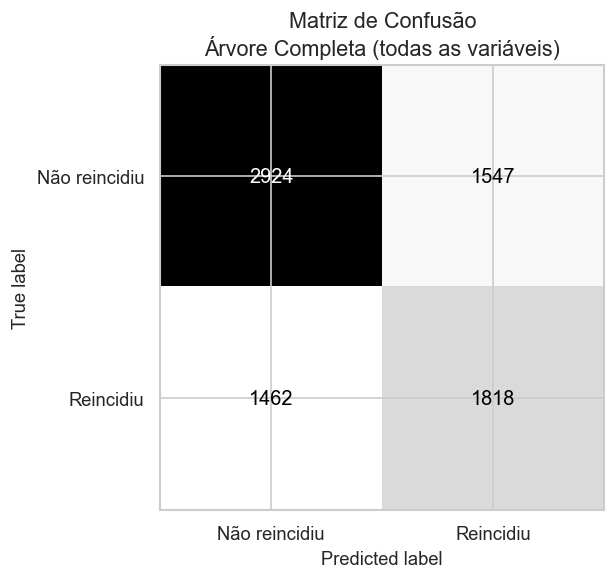


Profundidade da árvore : 27
Número de nós folha    : 3705


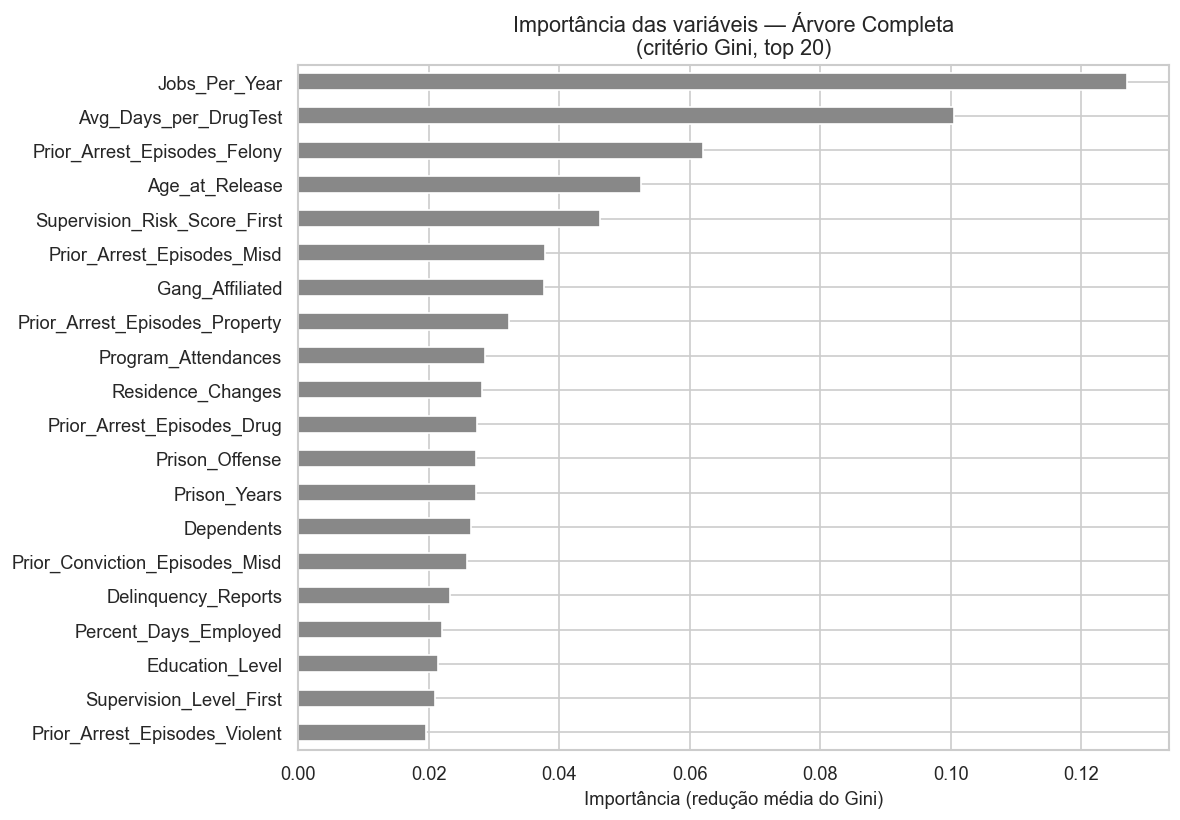


Top 20 variáveis mais importantes (Árvore Completa):
Jobs_Per_Year                     0.127038
Avg_Days_per_DrugTest             0.100544
Prior_Arrest_Episodes_Felony      0.061991
Age_at_Release                    0.052517
Supervision_Risk_Score_First      0.046268
Prior_Arrest_Episodes_Misd        0.037778
Gang_Affiliated                   0.037664
Prior_Arrest_Episodes_Property    0.032265
Program_Attendances               0.028565
Residence_Changes                 0.028195
Prior_Arrest_Episodes_Drug        0.027382
Prison_Offense                    0.027174
Prison_Years                      0.027172
Dependents                        0.026497
Prior_Conviction_Episodes_Misd    0.025912
Delinquency_Reports               0.023182
Percent_Days_Employed             0.021967
Education_Level                   0.021392
Supervision_Level_First           0.020904
Prior_Arrest_Episodes_Violent     0.019614


In [6]:
# Árvore sem restrição de profundidade, modelo completo
dt_completa = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_completa.fit(X_train, y_train)

metricas_completa = avaliar_modelo(
    'Árvore Completa (todas as variáveis)',
    dt_completa, X_train, y_train, X_test, y_test
)

print(f"\nProfundidade da árvore : {dt_completa.get_depth()}")
print(f"Número de nós folha    : {dt_completa.get_n_leaves()}")

# Importância das variáveis pela árvore completa
imp_completa = plot_importancias(
    dt_completa, FEATURES,
    'Importância das variáveis — Árvore Completa\n(critério Gini, top 20)',
    top_n=20
)

print("\nTop 20 variáveis mais importantes (Árvore Completa):")
print(imp_completa.to_string())

In [7]:

# Selecionar variáveis com importância acima da média
importancia_media = imp_completa.mean()
VARS_SELECIONADAS = imp_completa[imp_completa >= importancia_media].index.tolist()

print(f"Importância média (top 20)     : {importancia_media:.4f}")
print(f"Variáveis selecionadas ({len(VARS_SELECIONADAS)}):")
for v in VARS_SELECIONADAS:
    print(f"  {v:<45}  {imp_completa[v]:.4f}")


Importância média (top 20)     : 0.0397
Variáveis selecionadas (5):
  Jobs_Per_Year                                  0.1270
  Avg_Days_per_DrugTest                          0.1005
  Prior_Arrest_Episodes_Felony                   0.0620
  Age_at_Release                                 0.0525
  Supervision_Risk_Score_First                   0.0463


### Árvore de decisão com variáveis selecionadas


  Árvore com Variáveis Selecionadas (5 vars)
  Acurácia (treino) : 0.9729
  Acurácia (teste)  : 0.6062
  AUC-ROC           : 0.5903

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.6529    0.6775    0.6650      4471
    Reincidiu (1)     0.5366    0.5091    0.5225      3280

         accuracy                         0.6062      7751
        macro avg     0.5948    0.5933    0.5938      7751
     weighted avg     0.6037    0.6062    0.6047      7751



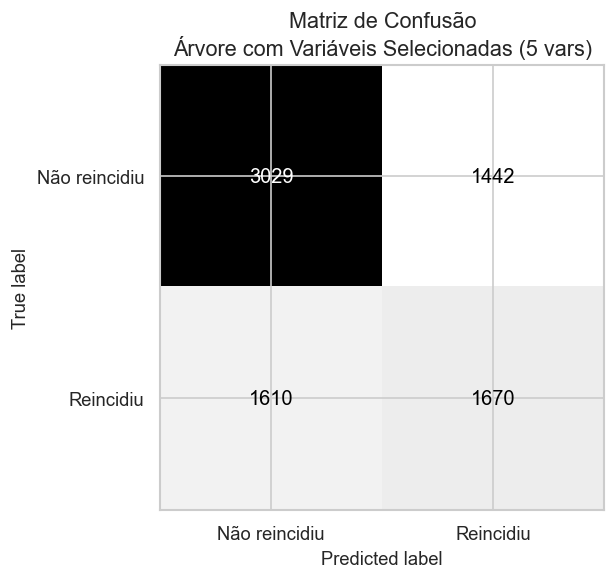


Profundidade da árvore : 39
Número de nós folha    : 5716


In [8]:

X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel  = X_test[VARS_SELECIONADAS]

dt_selecionada = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_selecionada.fit(X_train_sel, y_train)

metricas_selecionada = avaliar_modelo(
    f'Árvore com Variáveis Selecionadas ({len(VARS_SELECIONADAS)} vars)',
    dt_selecionada, X_train_sel, y_train, X_test_sel, y_test
)

print(f"\nProfundidade da árvore : {dt_selecionada.get_depth()}")
print(f"Número de nós folha    : {dt_selecionada.get_n_leaves()}")


REGRESSÃO LOGÍSTICA COM ANÁLISE DE SIGNIFICÂNCIA

COEFICIENTES ORDENADOS (Beta: Maior → Menor)

                    Variável      Beta      P-valor Significativo
                   Intercept -0.082005 1.140179e-02           Sim
              Age_at_Release  0.340820 0.000000e+00           Sim
               Jobs_Per_Year  0.139553 0.000000e+00           Sim
       Avg_Days_per_DrugTest -0.000327 1.015261e-05           Sim
Supervision_Risk_Score_First -0.019911 8.060298e-08           Sim
Prior_Arrest_Episodes_Felony -0.209196 0.000000e+00           Sim

✓ Significativas (p < 0.05): 5/5

MÉTRICAS DE DESEMPENHO

  Acurácia (treino) : 0.6614
  Acurácia (teste)  : 0.6591
  AUC-ROC           : 0.6975

CURVA KS (KOLMOGOROV-SMIRNOV)

  KS Estatística : 0.2915
  Interpretação : 29.2% de separação máxima


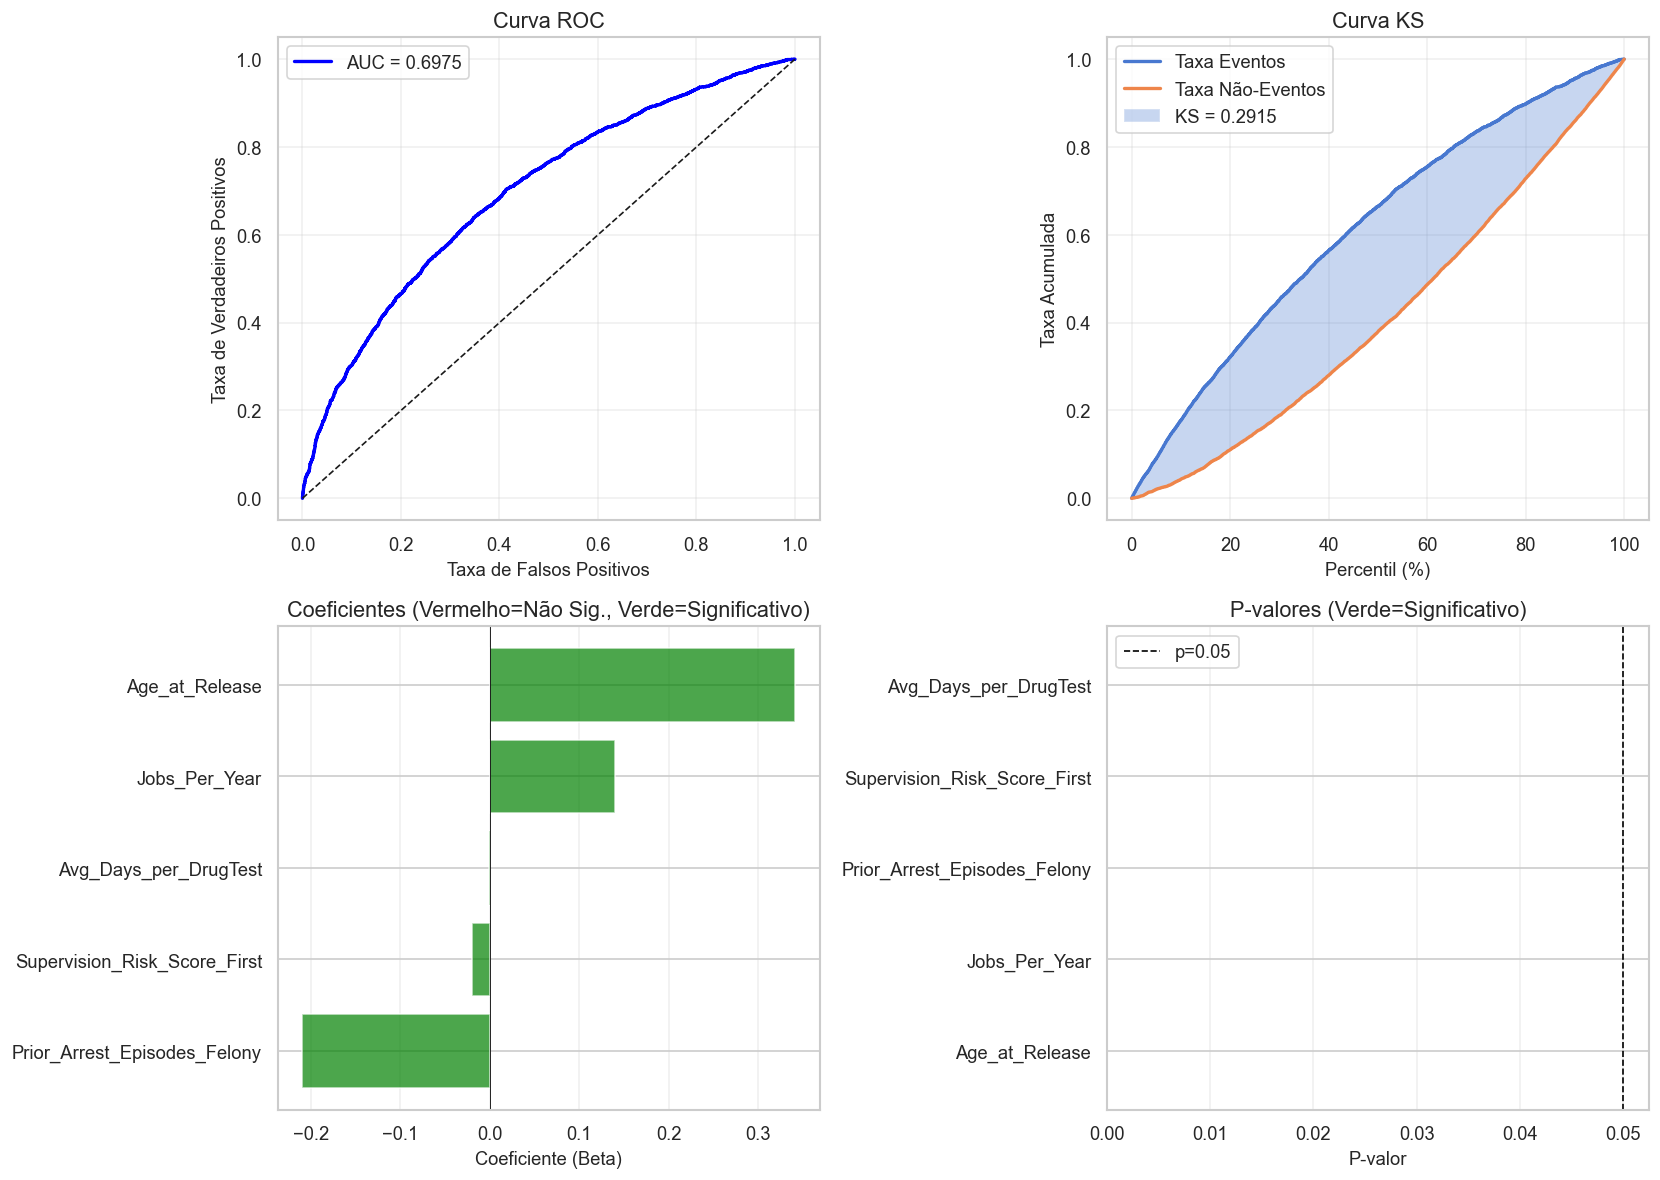


✅ Análise concluída!


In [11]:
# ============================================================================
# IMPORTS ADICIONAIS
# ============================================================================

import scipy.stats as stats
from sklearn.linear_model import LogisticRegression

# ============================================================================
# FUNÇÕES
# ============================================================================

def calcular_p_valor(X, y, coeficientes):
    y_pred = 1 / (1 + np.exp(-(X @ coeficientes)))
    residuos = y - y_pred
    pesos = y_pred * (1 - y_pred)
    X_ponderado = X * np.sqrt(pesos)[:, np.newaxis]
    XtX_inv = np.linalg.inv(X_ponderado.T @ X_ponderado)
    var_residuos = np.sum(residuos**2) / (len(y) - X.shape[1])
    erro_padrao = np.sqrt(np.diagonal(XtX_inv) * var_residuos)
    t_stats = coeficientes / erro_padrao
    p_valores = 2 * (1 - stats.t.cdf(np.abs(t_stats), len(y) - X.shape[1]))
    return p_valores, erro_padrao

def calcular_curva_ks(y_test, y_pred_proba):
    ordem = np.argsort(-y_pred_proba)
    y_test_ordenado = y_test.values[ordem] if hasattr(y_test, 'values') else y_test[ordem]
    total_eventos = np.sum(y_test_ordenado == 1)
    total_nao_eventos = np.sum(y_test_ordenado == 0)
    eventos_acum = np.cumsum(y_test_ordenado == 1)
    nao_eventos_acum = np.cumsum(y_test_ordenado == 0)
    taxa_eventos = eventos_acum / total_eventos
    taxa_nao_eventos = nao_eventos_acum / total_nao_eventos
    diferenca = taxa_eventos - taxa_nao_eventos
    ks_valor = np.max(diferenca)
    return {
        'ks_valor': ks_valor,
        'taxa_eventos': taxa_eventos,
        'taxa_nao_eventos': taxa_nao_eventos,
        'y_pred_proba_ordenado': y_pred_proba[ordem]
    }

# ============================================================================
# CÓDIGO PRINCIPAL
# ============================================================================

print("="*80)
print("REGRESSÃO LOGÍSTICA COM ANÁLISE DE SIGNIFICÂNCIA")
print("="*80)

# Preparar dados
X_train_sel = X_train[VARS_SELECIONADAS].values
X_test_sel = X_test[VARS_SELECIONADAS].values
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test

# Treinar modelo
lr_selecionada = LogisticRegression(random_state=SEED, max_iter=1000)
lr_selecionada.fit(X_train_sel, y_train_array)

y_pred_train = lr_selecionada.predict(X_train_sel)
y_pred_test = lr_selecionada.predict(X_test_sel)
y_pred_proba_test = lr_selecionada.predict_proba(X_test_sel)[:, 1]

# Calcular p-valores
X_train_com_intercept = np.column_stack([np.ones(X_train_sel.shape[0]), X_train_sel])
coef_com_intercept = np.concatenate([[lr_selecionada.intercept_[0]], lr_selecionada.coef_[0]])
p_valores, erro_padrao = calcular_p_valor(X_train_com_intercept, y_train_array, coef_com_intercept)

# DataFrame com coeficientes
df_coeficientes = pd.DataFrame({
    'Variável': ['Intercept'] + VARS_SELECIONADAS,
    'Beta': coef_com_intercept,
    'P-valor': p_valores,
    'Significativo': ['Sim'] + ['Sim' if p < 0.05 else 'Não' for p in p_valores[1:]]
})

# Ordenar por Beta (maior para menor)
df_coeficientes_ordenado = pd.concat([
    df_coeficientes.iloc[:1],
    df_coeficientes.iloc[1:].sort_values('Beta', ascending=False)
])

# Mostrar coeficientes
print("\n" + "="*80)
print("COEFICIENTES ORDENADOS (Beta: Maior → Menor)")
print("="*80)
print("\n" + df_coeficientes_ordenado.to_string(index=False))

# Contar significância
n_sig = sum(df_coeficientes['Significativo'] == 'Sim') - 1
print(f"\n✓ Significativas (p < 0.05): {n_sig}/{len(VARS_SELECIONADAS)}")

# Filtrar variáveis significativas
vars_significativas = df_coeficientes_ordenado[
    (df_coeficientes_ordenado['Variável'] != 'Intercept') & 
    (df_coeficientes_ordenado['P-valor'] < 0.05)
]['Variável'].tolist()

# Retreinar se necessário
if len(vars_significativas) < len(VARS_SELECIONADAS):
    print(f"\n→ Retreinando com {len(vars_significativas)} variáveis significativas...")
    
    X_train_sel = X_train[vars_significativas].values
    X_test_sel = X_test[vars_significativas].values
    
    lr_selecionada = LogisticRegression(random_state=SEED, max_iter=1000)
    lr_selecionada.fit(X_train_sel, y_train)
    
    y_pred_train = lr_selecionada.predict(X_train_sel)
    y_pred_test = lr_selecionada.predict(X_test_sel)
    y_pred_proba_test = lr_selecionada.predict_proba(X_test_sel)[:, 1]
    
    X_train_com_intercept = np.column_stack([np.ones(X_train_sel.shape[0]), X_train_sel])
    coef_com_intercept = np.concatenate([[lr_selecionada.intercept_[0]], lr_selecionada.coef_[0]])
    p_valores, erro_padrao = calcular_p_valor(X_train_com_intercept, y_train.values, coef_com_intercept)
    
    df_coeficientes = pd.DataFrame({
        'Variável': ['Intercept'] + vars_significativas,
        'Beta': coef_com_intercept,
        'P-valor': p_valores,
        'Significativo': ['Sim'] + ['Sim' if p < 0.05 else 'Não' for p in p_valores[1:]]
    })
    
    df_coeficientes_ordenado = pd.concat([
        df_coeficientes.iloc[:1],
        df_coeficientes.iloc[1:].sort_values('Beta', ascending=False)
    ])
    
    print("\n" + "="*80)
    print("COEFICIENTES FINAIS (Ordenados: Beta Maior → Menor)")
    print("="*80)
    print("\n" + df_coeficientes_ordenado.to_string(index=False))

# Métricas
acuracia_treino = accuracy_score(y_train, y_pred_train)
acuracia_teste = accuracy_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_pred_proba_test)

print("\n" + "="*80)
print("MÉTRICAS DE DESEMPENHO")
print("="*80)
print(f"\n  Acurácia (treino) : {acuracia_treino:.4f}")
print(f"  Acurácia (teste)  : {acuracia_teste:.4f}")
print(f"  AUC-ROC           : {auc:.4f}")

# Curva KS
ks_metricas = calcular_curva_ks(y_test, y_pred_proba_test)
ks_valor = ks_metricas['ks_valor']

print("\n" + "="*80)
print("CURVA KS (KOLMOGOROV-SMIRNOV)")
print("="*80)
print(f"\n  KS Estatística : {ks_valor:.4f}")
print(f"  Interpretação : {ks_valor:.1%} de separação máxima")

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Curva ROC
ax1 = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
ax1.plot(fpr, tpr, label=f'AUC = {auc:.4f}', linewidth=2, color='blue')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_xlabel('Taxa de Falsos Positivos')
ax1.set_ylabel('Taxa de Verdadeiros Positivos')
ax1.set_title('Curva ROC')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curva KS
ax2 = axes[0, 1]
percentis = np.arange(len(ks_metricas['taxa_eventos'])) / len(ks_metricas['taxa_eventos']) * 100
ax2.plot(percentis, ks_metricas['taxa_eventos'], label='Taxa Eventos', linewidth=2)
ax2.plot(percentis, ks_metricas['taxa_nao_eventos'], label='Taxa Não-Eventos', linewidth=2)
ax2.fill_between(percentis, ks_metricas['taxa_eventos'], ks_metricas['taxa_nao_eventos'], 
                  alpha=0.3, label=f'KS = {ks_valor:.4f}')
ax2.set_xlabel('Percentil (%)')
ax2.set_ylabel('Taxa Acumulada')
ax2.set_title('Curva KS')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Betas ordenados
ax3 = axes[1, 0]
df_plot = df_coeficientes_ordenado[df_coeficientes_ordenado['Variável'] != 'Intercept'].copy()
df_plot = df_plot.sort_values('Beta')
cores = ['red' if x >= 0.05 else 'green' for x in df_plot['P-valor']]
ax3.barh(df_plot['Variável'], df_plot['Beta'], color=cores, alpha=0.7)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Coeficiente (Beta)')
ax3.set_title('Coeficientes (Vermelho=Não Sig., Verde=Significativo)')
ax3.grid(True, alpha=0.3, axis='x')

# P-valores
ax4 = axes[1, 1]
df_pval = df_coeficientes_ordenado[df_coeficientes_ordenado['Variável'] != 'Intercept'].copy()
df_pval = df_pval.sort_values('P-valor')
cores_pval = ['green' if x < 0.05 else 'red' for x in df_pval['P-valor']]
ax4.barh(df_pval['Variável'], df_pval['P-valor'], color=cores_pval, alpha=0.7)
ax4.axvline(x=0.05, color='black', linestyle='--', linewidth=1, label='p=0.05')
ax4.set_xlabel('P-valor')
ax4.set_title('P-valores (Verde=Significativo)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Análise concluída!")
print("="*80)


  Indução de Regras com Variáveis Selecionadas (5 vars)
  Acurácia (treino) : 0.6690
  Acurácia (teste)  : 0.6684
  AUC-ROC           : 0.6976

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.6825    0.7951    0.7345      4471
    Reincidiu (1)     0.6397    0.4957    0.5586      3280

         accuracy                         0.6684      7751
        macro avg     0.6611    0.6454    0.6465      7751
     weighted avg     0.6644    0.6684    0.6601      7751



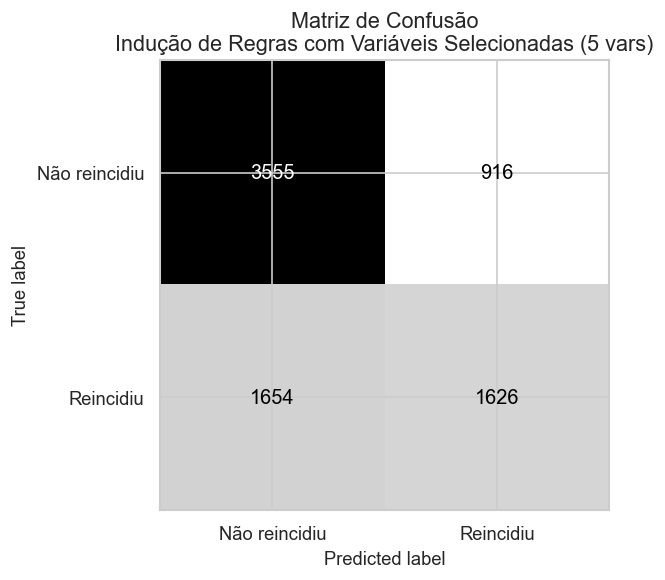


Profundidade da árvore : 5
Número de nós folha    : 32

Regras Induzidas:
|--- Prior_Arrest_Episodes_Felony <= 2.50
|   |--- Age_at_Release <= 1.50
|   |   |--- Jobs_Per_Year <= 0.07
|   |   |   |--- Supervision_Risk_Score_First <= 7.50
|   |   |   |   |--- Age_at_Release <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age_at_Release >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Supervision_Risk_Score_First >  7.50
|   |   |   |   |--- Prior_Arrest_Episodes_Felony <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Prior_Arrest_Episodes_Felony >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- Jobs_Per_Year >  0.07
|   |   |   |--- Prior_Arrest_Episodes_Felony <= 1.50
|   |   |   |   |--- Avg_Days_per_DrugTest <= 342.75
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Avg_Days_per_DrugTest >  342.75
|   |   |   |   |   |--- class: 1
|   |   |   |--- Prior_Arrest_Episodes_Felony >  1.50
|   |   |   |   |--- Jobs_Per_Year <= 1.01
|   |   

In [12]:
# ============================================================================
# INDUÇÃO DE REGRAS MELHORADA - Cole isto em uma célula do Jupyter
# ============================================================================

from sklearn.tree import DecisionTreeClassifier, export_text
import numpy as np

# Seus dados
X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel = X_test[VARS_SELECIONADAS]

# ✅ MODELO MELHORADO (adicione max_depth, min_samples_split, min_samples_leaf)
dt_regras = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,   
    random_state=SEED
)

dt_regras.fit(X_train_sel, y_train)

# Métricas
metricas_regras = avaliar_modelo(
    f'Indução de Regras com Variáveis Selecionadas ({len(VARS_SELECIONADAS)} vars)',
    dt_regras, X_train_sel, y_train, X_test_sel, y_test
)

print(f"\nProfundidade da árvore : {dt_regras.get_depth()}")
print(f"Número de nós folha    : {dt_regras.get_n_leaves()}")

# Regras em formato texto
print("\nRegras Induzidas:")
print(export_text(dt_regras, feature_names=VARS_SELECIONADAS))

# ============================================================================
# BÔNUS: EXTRAIR REGRAS EM FORMATO LEGÍVEL
# ============================================================================

def extrair_regras_legivel(dt, feature_names):
    """Extrai regras em formato fácil de ler"""
    tree = dt.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined"
        for i in tree.feature
    ]
    
    regras = []
    
    def navegar(node, condicoes):
        # Se é folha
        if tree.feature[node] == -2:
            classe = np.argmax(tree.value[node][0])
            valor_max = tree.value[node][0][classe]
            n_amostras = tree.n_node_samples[node]
            confianca = valor_max / n_amostras
            
            if condicoes:
                condicao_str = " E ".join(condicoes)
                regra = f"SE {condicao_str} ENTÃO classe={classe} (confiança={confianca:.0%})"
            else:
                regra = f"Classe padrão: {classe} (confiança={confianca:.0%})"
            
            regras.append(regra)
        
        # Se é nó interno
        else:
            feature = feature_name[node]
            threshold = tree.threshold[node]
            
            # Ramo esquerdo
            condicao_esq = f"{feature} <= {threshold:.3f}"
            navegar(tree.children_left[node], condicoes + [condicao_esq])
            
            # Ramo direito
            condicao_dir = f"{feature} > {threshold:.3f}"
            navegar(tree.children_right[node], condicoes + [condicao_dir])
    
    navegar(0, [])
    return regras


# Usar a função
print("\n" + "="*70)
print("REGRAS EM FORMATO LEGÍVEL:")
print("="*70)


regras = extrair_regras_legivel(dt_regras, VARS_SELECIONADAS)
for i, regra in enumerate(regras, 1):
    print(f"{i}. {regra}")

=== IMPACTO DA PROFUNDIDADE MÁXIMA ===
 max_depth  acuracia_treino  acuracia_teste      auc  n_folhas
         3         0.650188        0.653722 0.667713         8
         4         0.653063        0.657335 0.686545        16
         5         0.668989        0.668430 0.697640        32
         6         0.671588        0.663656 0.706618        62
         7         0.688343        0.668817 0.708663       115
         8         0.699624        0.671139 0.705653       201


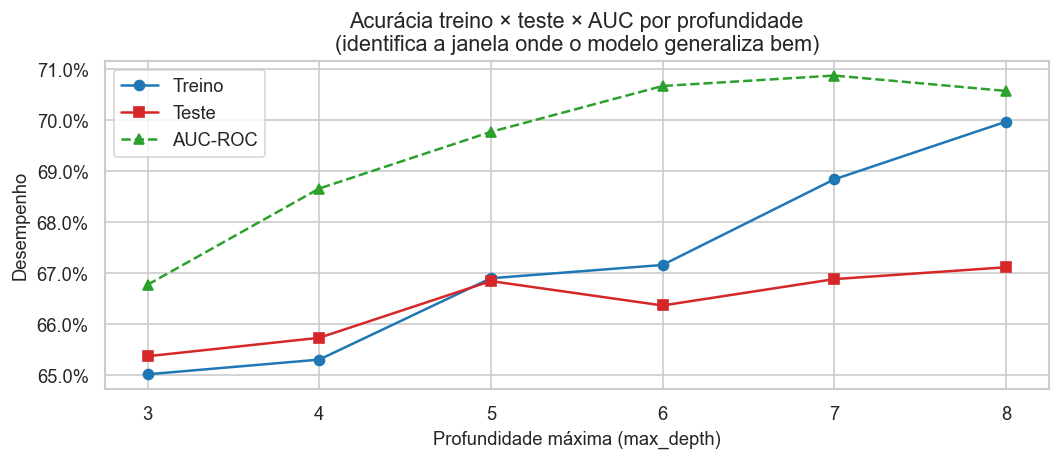

In [13]:
# Árvore PODADA com variáveis selecionadas (para apresentação)
# Árvores sem restrição são profundas demais para visualizar e tendem a
# overfitar. Aqui treinamos versões com profundidade limitada para
# interpretação e apresentação.

resultados_poda = []

for profundidade in [3, 4, 5, 6, 7, 8]:
    dt_pod = DecisionTreeClassifier(
        criterion='gini',
        max_depth=profundidade,
        random_state=SEED
    )
    dt_pod.fit(X_train_sel, y_train)
    y_pred  = dt_pod.predict(X_test_sel)
    y_proba = dt_pod.predict_proba(X_test_sel)[:, 1]
    resultados_poda.append({
        'max_depth':        profundidade,
        'acuracia_treino':  accuracy_score(y_train, dt_pod.predict(X_train_sel)),
        'acuracia_teste':   accuracy_score(y_test,  y_pred),
        'auc':              roc_auc_score(y_test,   y_proba),
        'n_folhas':         dt_pod.get_n_leaves(),
    })

df_poda = pd.DataFrame(resultados_poda)
print("=== IMPACTO DA PROFUNDIDADE MÁXIMA ===")
print(df_poda.to_string(index=False))

# Gráfico acurácia treino vs teste por profundidade
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_poda['max_depth'], df_poda['acuracia_treino'],
        marker='o', label='Treino', color='#1f77b4')
ax.plot(df_poda['max_depth'], df_poda['acuracia_teste'],
        marker='s', label='Teste',  color='#d62728')
ax.plot(df_poda['max_depth'], df_poda['auc'],
        marker='^', label='AUC-ROC', color='#2ca02c', linestyle='--')
ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('Desempenho')
ax.set_title('Acurácia treino × teste × AUC por profundidade\n'
             '(identifica a janela onde o modelo generaliza bem)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


Melhor profundidade (maior AUC no teste): 7

  Árvore Podada (max_depth=3, 5 vars)
  Acurácia (treino) : 0.6502
  Acurácia (teste)  : 0.6537
  AUC-ROC           : 0.6677

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.6827    0.7468    0.7133      4471
    Reincidiu (1)     0.6042    0.5268    0.5629      3280

         accuracy                         0.6537      7751
        macro avg     0.6434    0.6368    0.6381      7751
     weighted avg     0.6495    0.6537    0.6496      7751



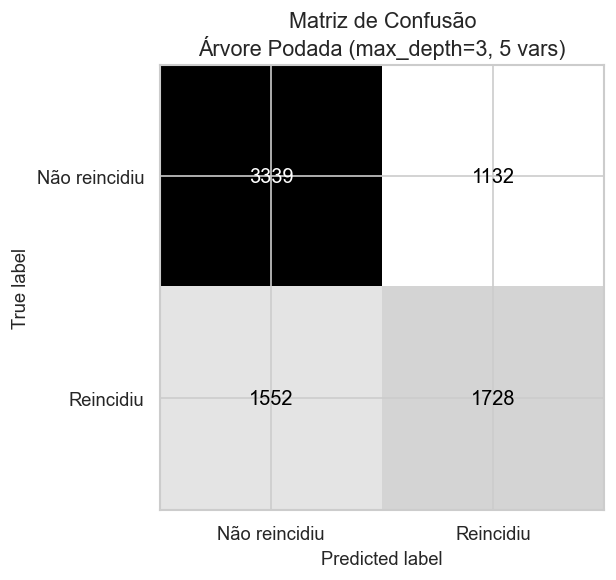

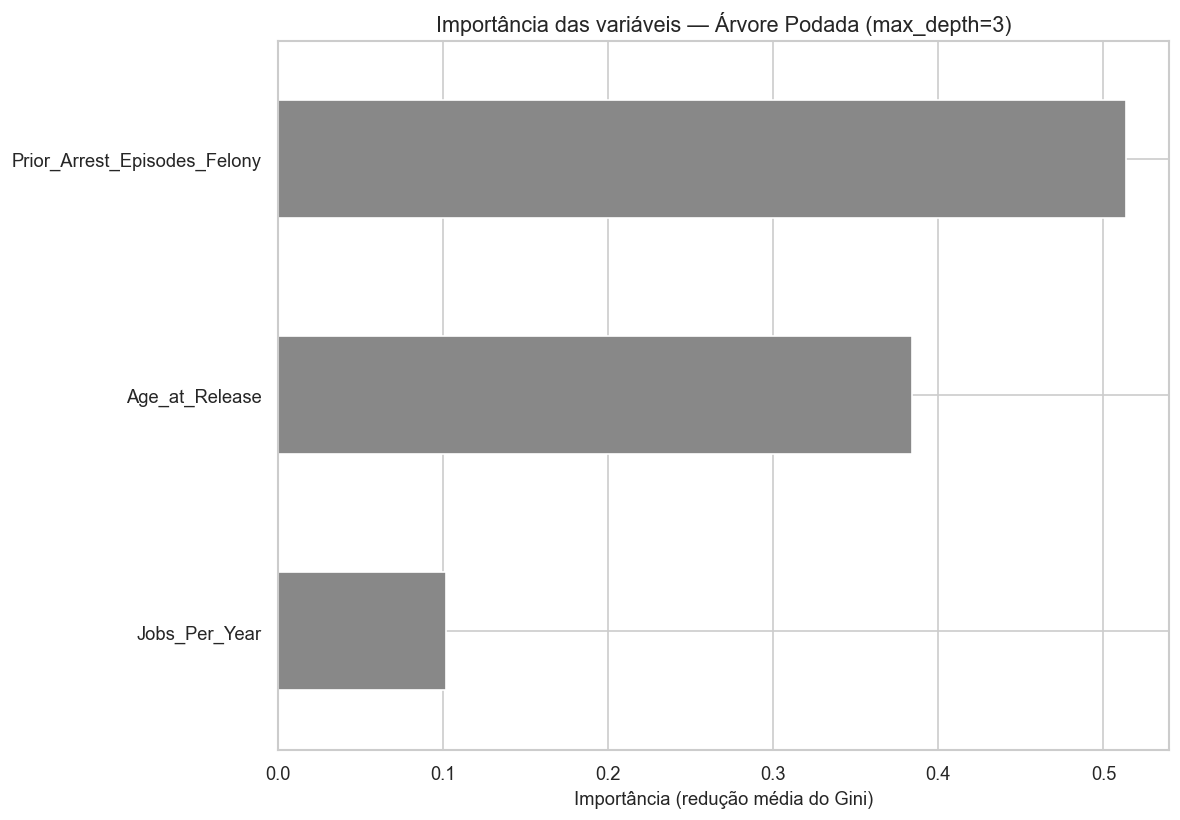

In [14]:
# Escolher a profundidade com maior AUC no teste (critério mais robusto que acurácia)
melhor_depth = df_poda.loc[df_poda['auc'].idxmax(), 'max_depth']
print(f"Melhor profundidade (maior AUC no teste): {melhor_depth}")
# Definindo o melhor deepth manualmente
melhor_depth = 3

dt_podada = DecisionTreeClassifier(
    criterion='gini',
    max_depth=melhor_depth,
    random_state=SEED
)
dt_podada.fit(X_train_sel, y_train)

metricas_podada = avaliar_modelo(
    f'Árvore Podada (max_depth={melhor_depth}, {len(VARS_SELECIONADAS)} vars)',
    dt_podada, X_train_sel, y_train, X_test_sel, y_test
)

# Importância na árvore podada
imp_podada = plot_importancias(
    dt_podada, VARS_SELECIONADAS,
    f'Importância das variáveis — Árvore Podada (max_depth={melhor_depth})'
)

In [15]:
# =============================================================================
# Árvore Podada — Visualização interativa com Plotly (escala de cinza)
# Zoom, pan e hover com informações detalhadas de cada nó
# Use o slider abaixo para controlar a profundidade visível
# =============================================================================

def _layout_arvore(tree, feature_names, max_vis_depth=None):
    """Calcula posições (x, y) dos nós da árvore usando layout tipo 'Reingold-Tilford' simples."""
    feature_names = list(feature_names)
    nos = []
    arestas = []

    def largura_sub(nid, depth):
        """Conta folhas visíveis na subárvore."""
        if tree.children_left[nid] == _tree.TREE_LEAF:
            return 1
        if max_vis_depth is not None and depth >= max_vis_depth:
            return 1
        return (largura_sub(int(tree.children_left[nid]), depth + 1) +
                largura_sub(int(tree.children_right[nid]), depth + 1))

    def posicionar(nid, depth, x_min, x_max):
        n = int(tree.n_node_samples[nid])
        v = tree.value[nid][0]
        total_v = float(v[0] + v[1])
        n_neg = int(round(float(v[0]) / total_v * n))
        n_pos = int(round(float(v[1]) / total_v * n))
        pct = round(n_pos / n * 100, 1) if n > 0 else 0
        gini = round(float(tree.impurity[nid]), 4)
        eh_folha = bool(tree.children_left[nid] == _tree.TREE_LEAF)
        cortada = False

        if not eh_folha and max_vis_depth is not None and depth >= max_vis_depth:
            eh_folha = False
            cortada = True

        x = (x_min + x_max) / 2
        y = -depth

        if eh_folha or cortada:
            if eh_folha:
                pred = 'Reincidiu' if n_pos > n_neg else 'Não reincidiu'
                regra = f'FOLHA → {pred}'
            else:
                feat = feature_names[int(tree.feature[nid])]
                thres = round(float(tree.threshold[nid]), 2)
                regra = f'{feat} ≤ {thres}'

            nos.append(dict(id=nid, x=x, y=y, regra=regra, n=n,
                            n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                            folha=eh_folha, cortada=cortada, depth=depth))
            return

        feat = feature_names[int(tree.feature[nid])]
        thres = round(float(tree.threshold[nid]), 2)
        regra = f'{feat} ≤ {thres}'

        nos.append(dict(id=nid, x=x, y=y, regra=regra, n=n,
                        n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                        folha=False, cortada=False, depth=depth))

        left = int(tree.children_left[nid])
        right = int(tree.children_right[nid])
        w_left = largura_sub(left, depth + 1)
        w_right = largura_sub(right, depth + 1)
        w_total = w_left + w_right
        x_split = x_min + (x_max - x_min) * w_left / w_total

        arestas.append((x, y, (x_min + x_split) / 2, -(depth + 1), 'Sim'))
        arestas.append((x, y, (x_split + x_max) / 2, -(depth + 1), 'Não'))

        posicionar(left, depth + 1, x_min, x_split)
        posicionar(right, depth + 1, x_split, x_max)

    posicionar(0, 0, 0, largura_sub(0, 0))
    return nos, arestas


def plotar_arvore_interativa(modelo, feature_names, titulo, max_depth_modelo):
    """Plota árvore interativa com plotly + slider ipywidgets para profundidade."""

    tree = modelo.tree_
    output = widgets.Output()

    def renderizar(depth):
        with output:
            output.clear_output(wait=True)
            nos, arestas = _layout_arvore(tree, feature_names, max_vis_depth=depth)

            fig = go.Figure()

            # Arestas
            for x0, y0, x1, y1, label in arestas:
                fig.add_trace(go.Scatter(
                    x=[x0, x1, None], y=[y0, y1, None],
                    mode='lines',
                    line=dict(color='rgb(160,160,160)', width=1.5),
                    hoverinfo='skip', showlegend=False,
                ))
                # Rótulo da aresta (Sim/Não)
                fig.add_annotation(
                    x=(x0 + x1) / 2, y=(y0 + y1) / 2,
                    text=f'<b>{label}</b>',
                    showarrow=False, font=dict(size=9, color='rgb(100,100,100)'),
                )

            # Nós
            xs = [n['x'] for n in nos]
            ys = [n['y'] for n in nos]
            textos = []
            hovers = []
            cores = []
            bordas = []
            tamanhos = []

            for n in nos:
                if n['folha']:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']}")
                    cor = 'rgb(220,220,220)'
                    borda = 'rgb(100,100,100)'
                    tam = 35
                elif n['cortada']:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']} [...]")
                    cor = 'rgb(245,245,245)'
                    borda = 'rgb(180,180,180)'
                    tam = 30
                else:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']}")
                    cor = 'rgb(240,240,240)'
                    borda = 'rgb(80,80,80)'
                    tam = 30

                hovers.append(
                    f"<b>{n['regra']}</b><br>"
                    f"Amostras: {n['n']}<br>"
                    f"Reincidiu: {n['n_pos']} ({n['pct']}%)<br>"
                    f"Não reincidiu: {n['n_neg']} ({round(100-n['pct'],1)}%)<br>"
                    f"Gini: {n['gini']}<br>"
                    f"Profundidade: {n['depth']}"
                )
                cores.append(cor)
                bordas.append(borda)
                tamanhos.append(tam)

            fig.add_trace(go.Scatter(
                x=xs, y=ys,
                mode='markers+text',
                marker=dict(
                    size=tamanhos,
                    color=cores,
                    line=dict(width=2, color=bordas),
                    symbol='square',
                ),
                text=textos,
                textposition='top center',
                textfont=dict(size=8),
                hovertext=hovers,
                hoverinfo='text',
                hoverlabel=dict(bgcolor='white', font_size=11),
                showlegend=False,
            ))

            fig.update_layout(
                title=f'{titulo}<br><sub>Profundidade visível: {depth} | Zoom e arraste para navegar</sub>',
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=''),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=''),
                template='plotly_white',
                width=1100,
                height=max(500, depth * 150),
                dragmode='pan',
            )
            fig.show(config={'scrollZoom': True, 'displayModeBar': True})

    slider = widgets.IntSlider(
        value=min(3, max_depth_modelo),
        min=1, max=max_depth_modelo,
        step=1, description='Profundidade:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
    )

    widgets.interactive_output(renderizar, {'depth': slider})
    display(slider, output)
    renderizar(slider.value)


# --- Plotar árvore podada interativa ---
plotar_arvore_interativa(
    modelo=dt_podada,
    feature_names=VARS_SELECIONADAS,
    titulo=f'Árvore de Decisão Podada (max_depth={melhor_depth})',
    max_depth_modelo=int(dt_podada.get_depth()),
)

# # Versão texto da árvore (útil para relatórios)
# print("\n=== ESTRUTURA DA ÁRVORE (texto) ===")
# print(export_text(dt_podada, feature_names=VARS_SELECIONADAS, max_depth=3))

IntSlider(value=3, description='Profundidade:', layout=Layout(width='500px'), max=3, min=1, style=SliderStyle(…

Output()

=== COMPARATIVO FINAL ===
                                       Acurácia Treino  Acurácia Teste  AUC-ROC
Modelo                                                                         
Árvore Completa (todas as vars)                 1.0000          0.6118   0.6041
Árvore Selecionada (5 vars, sem poda)           0.9729          0.6062   0.5903
Árvore Podada (max_depth=3)                     0.6502          0.6537   0.6677


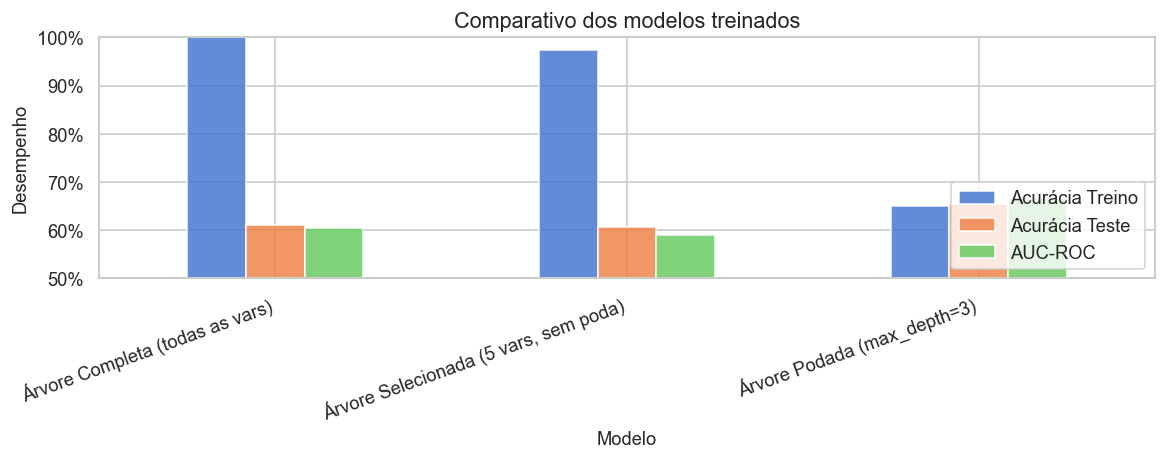

In [16]:

df_comparativo = pd.DataFrame([
    {'Modelo': 'Árvore Completa (todas as vars)',
     **metricas_completa},
    {'Modelo': f'Árvore Selecionada ({len(VARS_SELECIONADAS)} vars, sem poda)',
     **metricas_selecionada},
    {'Modelo': f'Árvore Podada (max_depth={melhor_depth})',
     **metricas_podada},
]).set_index('Modelo')

df_comparativo.columns = ['Acurácia Treino', 'Acurácia Teste', 'AUC-ROC']
print("=== COMPARATIVO FINAL ===")
print(df_comparativo.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df_comparativo.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Desempenho')
ax.set_title('Comparativo dos modelos treinados')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# Árvore COMPLETA interativa (max_depth=5 para visualização)
# Escala de cinza, com slider de profundidade e hover detalhado
# =============================================================================

dt_completa_viz = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=SEED
)
dt_completa_viz.fit(X_train, y_train)

plotar_arvore_interativa(
    modelo=dt_completa_viz,
    feature_names=FEATURES,
    titulo='Árvore Completa — Todas as Variáveis (max_depth=5)',
    max_depth_modelo=int(dt_completa_viz.get_depth()),
)

IntSlider(value=3, description='Profundidade:', layout=Layout(width='500px'), max=5, min=1, style=SliderStyle(…

Output()

In [18]:
# =============================================================================
# Árvores interativas HTML (D3.js) — responsivas, clicáveis, escala de cinza
# Clique em qualquer nó para expandir/colapsar seus filhos
# Layout ocupa 100% da tela do navegador com botão "Ajustar à tela"
# =============================================================================

import json
from IPython.display import IFrame, display as ipy_display


def tree_para_json(modelo, feature_names, classe_alvo_nome='Reincidência'):
    """Converte árvore sklearn em dicionário JSON para D3."""
    tree = modelo.tree_
    feature_names = list(feature_names)

    def construir_no(nid):
        n = int(tree.n_node_samples[nid])
        v = tree.value[nid][0]
        total_v = float(v[0] + v[1])
        n_neg = int(round(float(v[0]) / total_v * n))
        n_pos = int(round(float(v[1]) / total_v * n))
        pct = round(n_pos / n * 100, 1)
        gini = round(float(tree.impurity[nid]), 4)
        eh_folha = bool(tree.children_left[nid] == _tree.TREE_LEAF)

        if eh_folha:
            regra = 'Folha'
            pred = 'Reincidiu' if n_pos > n_neg else 'Não reincidiu'
        else:
            feat = feature_names[int(tree.feature[nid])]
            thres = round(float(tree.threshold[nid]), 3)
            regra = f'{feat} \u2264 {thres}'
            pred = None

        no = dict(id=int(nid), regra=str(regra), n=n,
                  n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                  folha=eh_folha,
                  pred=str(pred) if pred else None,
                  classe_alvo=str(classe_alvo_nome))

        if not eh_folha:
            esq = int(tree.children_left[nid])
            dir_ = int(tree.children_right[nid])
            no['children'] = [construir_no(esq), construir_no(dir_)]
            no['children'][0]['lado'] = 'sim'
            no['children'][1]['lado'] = 'nao'
        return no

    return construir_no(0)


def gerar_arvore_html(modelo, feature_names,
                      titulo='Árvore de Decisão Interativa',
                      classe_alvo_nome='Reincidência',
                      arquivo='arvore_decisao/arvore_interativa.html'):
    tree_json_str = json.dumps(
        tree_para_json(modelo, feature_names, classe_alvo_nome),
        ensure_ascii=False
    )

    html = '<!DOCTYPE html>\n'
    html += '<html lang="pt-BR">\n<head>\n<meta charset="UTF-8">\n'
    html += '<meta name="viewport" content="width=device-width, initial-scale=1.0">\n'
    html += f'<title>{titulo}</title>\n'
    html += '<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>\n'
    html += """<style>
*{margin:0;padding:0;box-sizing:border-box;}
html,body{width:100%;height:100%;overflow:hidden;font-family:'Segoe UI',Arial,sans-serif;background:#fafafa;}
.app{display:flex;flex-direction:column;width:100vw;height:100vh;}
#header{background:#333;color:white;padding:10px 20px;font-size:15px;font-weight:bold;
        display:flex;justify-content:space-between;align-items:center;flex-shrink:0;}
#legend{background:#f5f5f5;padding:6px 20px;font-size:11px;border-bottom:1px solid #ddd;
        display:flex;gap:16px;align-items:center;flex-wrap:wrap;flex-shrink:0;}
.leg-item{display:flex;align-items:center;gap:5px;}
.leg-box{width:14px;height:14px;border-radius:2px;border:1px solid #999;flex-shrink:0;}
#controls{background:#f5f5f5;padding:6px 20px;font-size:12px;border-bottom:1px solid #ddd;
          display:flex;gap:10px;align-items:center;flex-shrink:0;}
button{padding:4px 10px;border:1px solid #aaa;border-radius:3px;cursor:pointer;
       background:#eee;font-size:11px;}
button:hover{background:#ddd;}
#tree-container{flex:1;width:100%;overflow:hidden;position:relative;}
svg{width:100%;height:100%;display:block;cursor:grab;}
svg:active{cursor:grabbing;}
.link{fill:none;stroke:#bbb;stroke-width:1.8px;}
.link-label{font-size:10px;font-style:italic;font-weight:bold;}
.node rect{cursor:pointer;transition:stroke-width 0.15s;}
.node rect:hover{stroke-width:3px;stroke:#333;}
.node text{pointer-events:none;}
.node-folha>rect:first-child{stroke-dasharray:5,3;}
.node-collapsed>rect:first-child{stroke:#555;stroke-width:2.5px;}
</style>
</head>
<body>
<div class="app">
"""
    html += f'<div id="header"><span>{titulo}</span>'
    html += '<span style="font-size:11px;font-weight:normal;color:#ccc;">Escala de cinza | Clique nos n\u00f3s para expandir/colapsar</span></div>\n'
    html += """<div id="legend">
  <div class="leg-item"><div class="leg-box" style="background:#444"></div>Gini&asymp;0 (puro)</div>
  <div class="leg-item"><div class="leg-box" style="background:#999"></div>Gini&asymp;0.25</div>
  <div class="leg-item"><div class="leg-box" style="background:#ddd"></div>Gini&asymp;0.5 (m&aacute;x)</div>
  <div class="leg-item"><div class="leg-box" style="background:white;border:2px dashed #666;"></div>Folha</div>
  <div class="leg-item"><div class="leg-box" style="background:#eee;border:2.5px solid #555;"></div>Colapsado</div>
</div>
<div id="controls">
  <button onclick="expandAll()">&#9660; Expandir tudo</button>
  <button onclick="collapseAll()">&#9650; Colapsar tudo</button>
  <button onclick="resetZoom()">&#8635; Resetar zoom</button>
  <button onclick="fitToScreen()">&#8862; Ajustar &agrave; tela</button>
  <span style="color:#888;font-size:10px;">Scroll=zoom | Arraste=mover | Clique=expandir/colapsar</span>
</div>
<div id="tree-container"></div>
</div>
<script>
"""
    html += f'const DATA={tree_json_str};\n'
    html += """const NODE_W=220,NODE_H=92,H_GAP=24,V_GAP=50;

function giniCor(g){
  var t=Math.min(g/0.5,1);
  var v=Math.round(68+(221-68)*t);
  return 'rgb('+v+','+v+','+v+')';
}
function headerCor(g){
  var t=Math.min(g/0.5,1);
  var v=Math.max(0,Math.round(68+(221-68)*t)-25);
  return 'rgb('+v+','+v+','+v+')';
}
function textCor(g){return g<0.35?'white':'#111';}

var collapsed=new Set();

function cloneTree(d){
  var n=Object.assign({},d);
  if(d.children&&!collapsed.has(d.id)){
    n.children=d.children.map(cloneTree);
  }else{
    n._kids=d.children||d._kids||null;
    n.children=null;
  }
  return n;
}

var container=document.getElementById('tree-container');
var svg=d3.select('#tree-container').append('svg');
var gEl=svg.append('g');
var zoomBehavior=d3.zoom().scaleExtent([0.05,4]).on('zoom',function(e){gEl.attr('transform',e.transform);});
svg.call(zoomBehavior);

function resetZoom(){svg.transition().duration(400).call(zoomBehavior.transform,d3.zoomIdentity.translate(60,40).scale(0.8));}

function fitToScreen(){
  var bounds=gEl.node().getBBox();
  if(!bounds.width)return;
  var cw=container.clientWidth,ch=container.clientHeight;
  var scale=Math.min(cw/(bounds.width+80),ch/(bounds.height+80),1.5);
  var tx=cw/2-(bounds.x+bounds.width/2)*scale;
  var ty=ch/2-(bounds.y+bounds.height/2)*scale;
  svg.transition().duration(500).call(zoomBehavior.transform,
    d3.zoomIdentity.translate(tx,ty).scale(scale));
}

function render(){
  gEl.selectAll('*').remove();
  var root=d3.hierarchy(cloneTree(DATA),function(d){return d.children;});
  d3.tree().nodeSize([NODE_W+H_GAP,NODE_H+V_GAP])(root);

  var descs=root.descendants();
  var xs=descs.map(function(d){return d.x;}),ys=descs.map(function(d){return d.y;});
  var minX=Math.min.apply(null,xs)-NODE_W/2-30,maxX=Math.max.apply(null,xs)+NODE_W/2+30;
  var minY=Math.min.apply(null,ys)-30,maxY=Math.max.apply(null,ys)+NODE_H+30;
  var ox=-minX+10,oy=-minY+10;

  gEl.selectAll('.link').data(root.links()).join('path').attr('class','link')
    .attr('d',function(d){
      var sx=d.source.x+ox,sy=d.source.y+NODE_H+oy;
      var tx=d.target.x+ox,ty=d.target.y+oy;
      var my=(sy+ty)/2;
      return 'M'+sx+','+sy+' C'+sx+','+my+' '+tx+','+my+' '+tx+','+ty;
    });

  gEl.selectAll('.link-label').data(root.links()).join('text').attr('class','link-label')
    .attr('x',function(d){return(d.source.x+d.target.x)/2+ox+(d.target.data.lado==='sim'?-16:16);})
    .attr('y',function(d){return(d.source.y+NODE_H+d.target.y)/2+oy;})
    .attr('text-anchor','middle')
    .attr('fill',function(d){return d.target.data.lado==='sim'?'#555':'#888';})
    .text(function(d){return d.target.data.lado==='sim'?'Sim':'N\\u00e3o';});

  var nodes=gEl.selectAll('.node').data(descs).join('g')
    .attr('class',function(d){
      var c='node';
      if(d.data.folha)c+=' node-folha';
      if(!d.data.folha&&collapsed.has(d.data.id))c+=' node-collapsed';
      return c;
    })
    .attr('transform',function(d){return 'translate('+(d.x+ox-NODE_W/2)+','+(d.y+oy)+')';});

  nodes.append('rect')
    .attr('width',NODE_W).attr('height',NODE_H).attr('rx',6).attr('ry',6)
    .attr('fill',function(d){return giniCor(d.data.gini);})
    .attr('stroke','#777').attr('stroke-width',1.5)
    .on('click',function(ev,d){
      ev.stopPropagation();
      if(d.data.folha)return;
      if(collapsed.has(d.data.id)){collapsed.delete(d.data.id);}else{collapsed.add(d.data.id);}
      render();
    });

  nodes.filter(function(d){return !d.data.folha;}).append('rect')
    .attr('width',NODE_W).attr('height',24).attr('rx',6).attr('ry',6)
    .attr('fill',function(d){return headerCor(d.data.gini);}).style('pointer-events','none');

  nodes.append('line')
    .attr('x1',0).attr('x2',NODE_W).attr('y1',24).attr('y2',24)
    .attr('stroke','rgba(0,0,0,0.1)').attr('stroke-width',1)
    .style('pointer-events','none');

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',16).attr('text-anchor','middle')
    .attr('font-size',10).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return d.data.regra.length>28?d.data.regra.slice(0,27)+'\\u2026':d.data.regra;})
    .append('title').text(function(d){return d.data.regra;});

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',44).attr('text-anchor','middle')
    .attr('font-size',13).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return '% Reincid\\u00eancia: '+d.data.pct+'%';});

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',60).attr('text-anchor','middle')
    .attr('font-size',9).attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return 'n = '+d.data.n.toLocaleString('pt-BR')+'   Gini = '+d.data.gini;});

  nodes.filter(function(d){return d.data.folha;}).append('text')
    .attr('x',NODE_W/2).attr('y',78).attr('text-anchor','middle')
    .attr('font-size',10).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return '\\u2192 '+d.data.pred;});

  nodes.filter(function(d){return !d.data.folha;}).append('text')
    .attr('x',NODE_W/2).attr('y',78).attr('text-anchor','middle')
    .attr('font-size',9).attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return collapsed.has(d.data.id)?'\\u25b6 clique para expandir':'\\u25c0 clique para colapsar';});
}

function expandAll(){collapsed.clear();render();setTimeout(fitToScreen,100);}
function collapseAll(){
  function col(d){if(d.children){collapsed.add(d.id);d.children.forEach(col);}}
  if(DATA.children)DATA.children.forEach(col);
  render();setTimeout(fitToScreen,100);
}

render();
setTimeout(fitToScreen,200);
window.addEventListener('resize',function(){setTimeout(fitToScreen,100);});
</script>
</body>
</html>"""

    with open(arquivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"\u2713 Árvore salva em '{arquivo}' — abra no navegador para interagir.")
    ipy_display(IFrame(src=arquivo, width='100%', height=700))


# --- Gerar árvore podada ---
gerar_arvore_html(
    modelo=dt_podada,
    feature_names=VARS_SELECIONADAS,
    titulo=f'Árvore Podada — Variáveis Selecionadas (max_depth={melhor_depth})',
    classe_alvo_nome='Reincidência',
    arquivo='arvore_decisao/arvore_podada_interativa.html',
)

# --- Gerar árvore completa (max_depth=5) ---
gerar_arvore_html(
    modelo=dt_completa_viz,
    feature_names=FEATURES,
    titulo='Árvore Completa — Todas as Variáveis (max_depth=5)',
    classe_alvo_nome='Reincidência',
    arquivo='arvore_decisao/arvore_completa_interativa.html',
)

✓ Árvore salva em 'arvore_decisao/arvore_podada_interativa.html' — abra no navegador para interagir.


✓ Árvore salva em 'arvore_decisao/arvore_completa_interativa.html' — abra no navegador para interagir.
